In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

In [2]:
train = pd.read_csv(r'C:\Users\viji-\OneDrive\Desktop\Titanic\Data\train (1).csv')
test = pd.read_csv(r'C:\Users\viji-\OneDrive\Desktop\Titanic\Data\test (1).csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


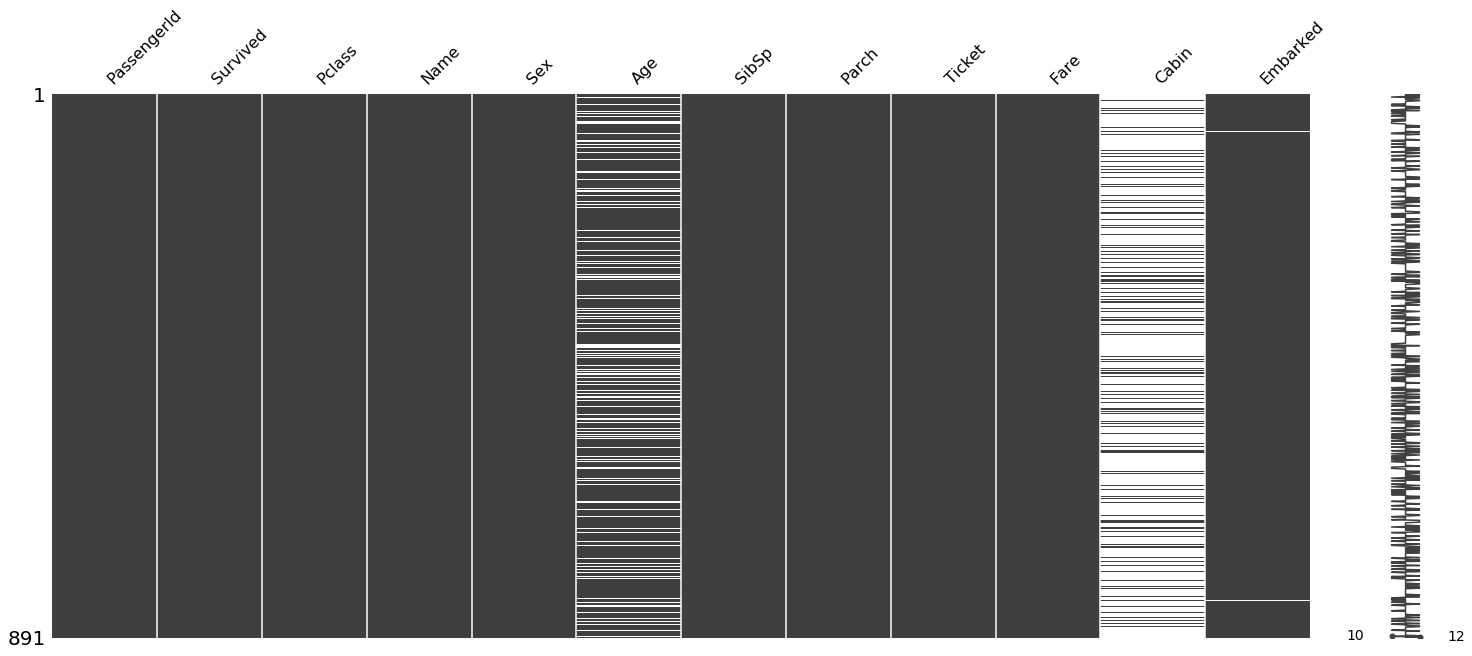

In [5]:
missingno.matrix(train, )

Cabin and Age have a lot of missing values, embarked has very few

### Dependent Column

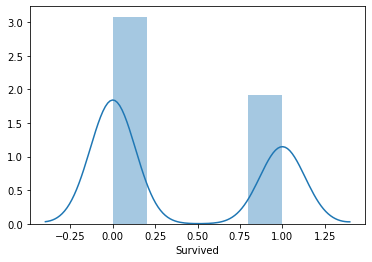

In [6]:
sns.distplot(train['Survived'])

In [7]:
train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

Correlation between gender and survival

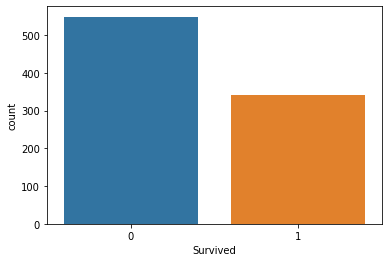

In [8]:
sns.countplot(x = 'Survived', data= train)

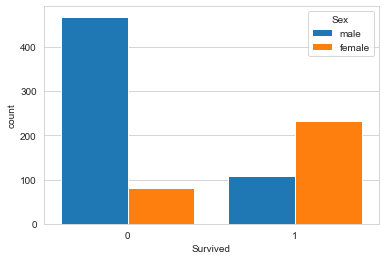

In [9]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', hue = 'Sex', data = train, saturation = 1)

Correlation of passenger class with survival

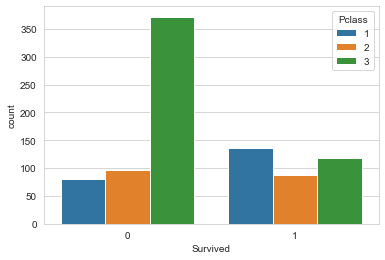

In [10]:
sns.countplot(x = 'Survived', hue = 'Pclass', data = train)

C:\Users\viji-\Documents\python ML\lib\site-packages\numpy\lib\histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
C:\Users\viji-\Documents\python ML\lib\site-packages\numpy\lib\histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
C:\Users\viji-\Documents\python ML\lib\site-packages\statsmodels\nonparametric\kde.py:447: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
C:\Users\viji-\Documents\python ML\lib\site-packages\statsmodels\nonparametric\kde.py:447: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


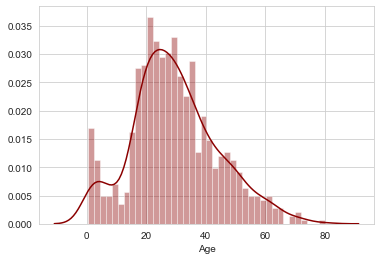

In [11]:
sns.distplot(train['Age'], kde = True, color = 'darkred', bins = 40)

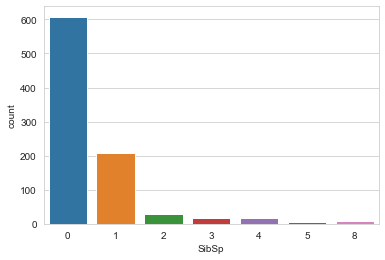

In [12]:
sns.countplot(x = 'SibSp', data = train)

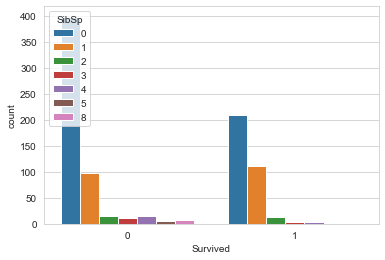

In [13]:
sns.countplot(x = 'Survived', hue = 'SibSp', data = train)

### Data Cleaning 

In [14]:
train.groupby('Pclass')['Age'].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [15]:
def impute_age(cols):
    
    Age, Pclass = cols
    if pd.isnull(Age):    
        if Pclass == 1:
            return 37.0
        elif Pclass == 2:
            return 29.0
        else:
            return 24
    else:
        return Age

In [16]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis = 1)

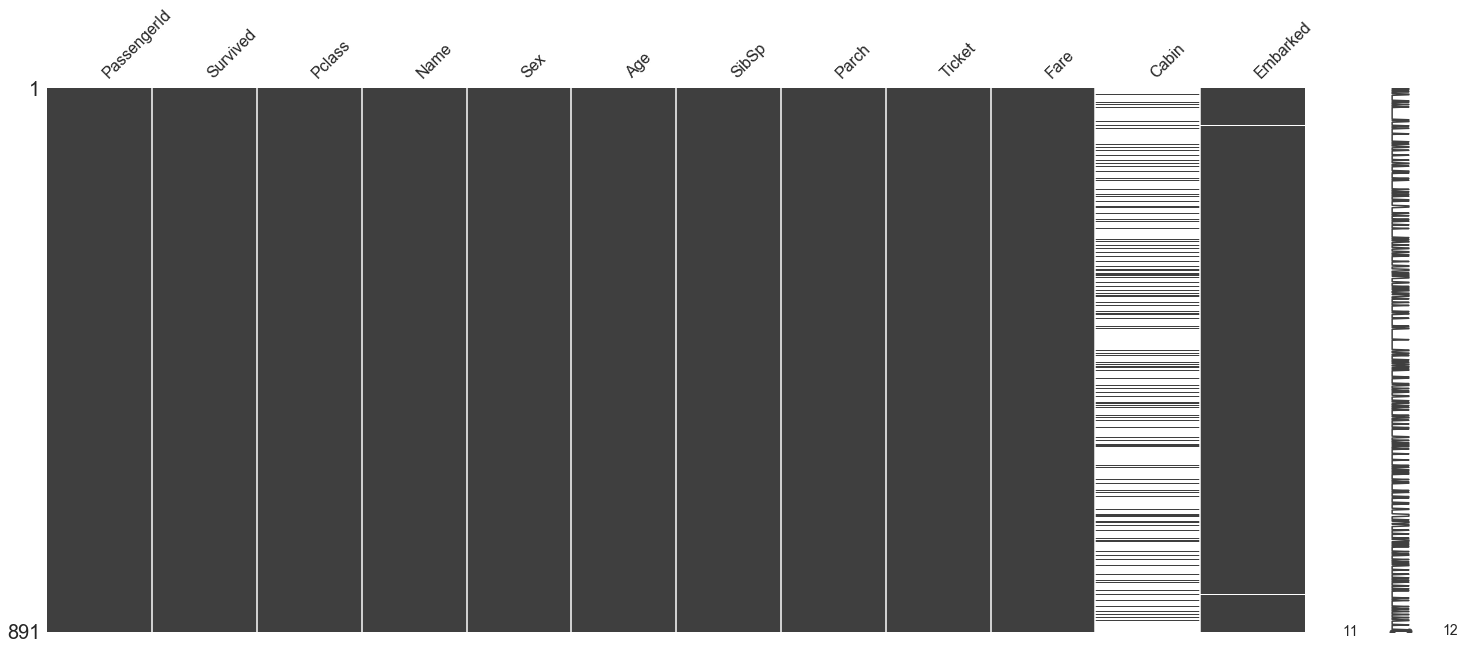

In [24]:
missingno.matrix(train)

Since the number of missing values in embarked are just 2 we can drop those rows without losing much information

In [33]:
train['Embarked'].dropna(axis = 0, inplace = True)

The number of missing records in the Cabin column is too high thus imputation will not work there

In [26]:
train.drop('Cabin', 1, inplace = True)

The columns PassengerId Name and Ticket do not provide useful information to predict survival

In [27]:
train.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

### Converting Categorical Features:

In [28]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [29]:
train['Sex'].nunique()

2

In [34]:
train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [35]:
def gender_map(x):
    if x == 'male':
        return 0 
    elif x =='female':
        return 1

In [36]:
df = train.copy()

In [37]:
train['Sex'] = train['Sex'].apply(lambda x: gender_map(x))

In [38]:
train = pd.concat([train.drop('Embarked', 1), pd.get_dummies(train['Embarked'], drop_first = True)], axis = 1)

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived', 1), train['Survived'], test_size= 0.2)

### Model Building

In [41]:
from catboost import Pool, CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [42]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.naive_bayes import BernoulliNB, GaussianNB

##### We will we using the following classifiers and comparing them to see which gives the best result
1. Catboost    
2. GB Classifier     
3. Logistic regression      
4. Support Vector Machine       
5. KNN      
6. Bernoulli
7. Gaussian Classifier
8. RandomForestClassifier

### 1. Random Forest 

In [85]:
model_rf = RandomForestClassifier(n_estimators = 30, n_jobs = -1, max_features= 0.5)

In [86]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features=0.5, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=30, n_jobs=-1,
                       oob_score=False, random_state=None, verbose=0,
                       warm_start=False)

In [87]:
model_rf.score(X_test, y_test)

0.8044692737430168

### 2. Gradient Boosted Trees

In [91]:
model_gbt = GradientBoostingClassifier(max_features = 0.5)

In [92]:
model_gbt.fit(X_train, y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=0.5, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='auto',
                           random_state=None, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [93]:
model_gbt.score(X_test, y_test)

0.7988826815642458

#### 3. Logestic Regression:

In [95]:
model_lr = LogisticRegression()

In [96]:
model_lr.fit(X_train, y_train)

C:\Users\viji-\Documents\python ML\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [98]:
model_lr.score(X_test, y_test)

0.7821229050279329

### 4. Gaussian 

In [99]:
model_gnb = GaussianNB()

In [100]:
model_gnb.fit(X_train, y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [102]:
model_gnb.score(X_test, y_test)

0.776536312849162

### 5. Bernoulli

In [103]:
model_bnb = BernoulliNB(alpha = 0.7)

In [104]:
model_bnb.fit(X_train, y_train)

BernoulliNB(alpha=0.7, binarize=0.0, class_prior=None, fit_prior=True)

In [105]:
model_bnb.score(X_test, y_test)

0.776536312849162

### 6. KNN 

In [106]:
model_knn = KNN(5, n_jobs = -1)

In [107]:
model_knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform')

In [108]:
model_knn.score(X_test, y_test)

0.7262569832402235

### 7. SVM

In [109]:
model_svm = SVC()

In [110]:
model_svm.fit(X_train, y_train)

C:\Users\viji-\Documents\python ML\lib\site-packages\sklearn\svm\base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='rbf', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

In [111]:
model_svm.score(X_test, y_test)

0.7486033519553073

### 8. Catboost

In [112]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(df.drop('Survived', 1), df['Survived'], 
                                                            test_size= 0.2)

In [117]:
cat_features = ['Sex', 'Embarked']

model_cb = CatBoostClassifier(iterations = 100, eval_metric = 'Accuracy')
model_cb.fit(X_train_2, y_train_2, cat_features = cat_features, eval_set = (X_test_2, y_test_2), plot = True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.079309
0:	learn: 0.7749648	test: 0.8370787	best: 0.8370787 (0)	total: 14ms	remaining: 1.38s
1:	learn: 0.7904360	test: 0.8707865	best: 0.8707865 (1)	total: 21ms	remaining: 1.03s
2:	learn: 0.7679325	test: 0.8595506	best: 0.8707865 (1)	total: 22.3ms	remaining: 721ms
3:	learn: 0.7946554	test: 0.8651685	best: 0.8707865 (1)	total: 29.2ms	remaining: 701ms
4:	learn: 0.7946554	test: 0.8651685	best: 0.8707865 (1)	total: 31.4ms	remaining: 596ms
5:	learn: 0.7946554	test: 0.8595506	best: 0.8707865 (1)	total: 33.5ms	remaining: 526ms
6:	learn: 0.7946554	test: 0.8595506	best: 0.8707865 (1)	total: 34.8ms	remaining: 462ms
7:	learn: 0.7946554	test: 0.8651685	best: 0.8707865 (1)	total: 36.6ms	remaining: 421ms
8:	learn: 0.7946554	test: 0.8707865	best: 0.8707865 (1)	total: 38.7ms	remaining: 391ms
9:	learn: 0.8030942	test: 0.8707865	best: 0.8707865 (1)	total: 40.6ms	remaining: 365ms
10:	learn: 0.7988748	test: 0.8651685	best: 0.8707865 (1)	total: 42ms	remaining: 340ms
11:	learn: 0.79465